# Student Score Visualizations
Three ways to visualize student assessment data using Seaborn.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

grades_df = pd.DataFrame({
    'student_id': [2457625, 1758293, 1622247],
    'final_exam': [79, 92, 71],
    'midterm': [68, 73, 87],
    'individual_project': [71, 67, 74],
    'group_project': [83, 56, 77]
})

# Transform from "wide" to "long" format using pd.melt()
# Wide format: each assignment type is a separate column
# Long format: all assignment types go into one column, scores into another
long_grades_df = pd.melt(
    grades_df,                          # The DataFrame to transform
    id_vars=['student_id'],             # Columns to keep as identifiers (don't melt these)
    var_name='assignment_type',         # Name for the new column that will contain the old column names
    value_name='score'                  # Name for the new column that will contain the values
)

# Convert student_id to string for categorical plotting
long_grades_df['student_id'] = long_grades_df['student_id'].astype(str)

# Wide format with student_id as index for heatmap
df_heat = grades_df.set_index('student_id')

print(grades_df)

   student_id  final_exam  midterm  individual_project  group_project
0     2457625          79       68                  71             83
1     1758293          92       73                  67             56
2     1622247          71       87                  74             77


## Without Melting: Plotting Directly from Wide Format
You can plot without melting by iterating over columns manually. It's more verbose but useful to understand what `melt` is saving you from.

This code builds a grouped bar chart by iterating over assessments (the columns), drawing one full set of bars per assessment — so in each loop iteration, we're placing one bar for every student.

The challenge with doing this manually is positioning: if you just called ax.bar() with the same x positions each time, all four sets of bars would overlap. The offset calculation solves this by shifting each set of bars slightly left or right so that the four bars belonging to the same student end up neatly grouped and centered on that student's tick mark.
So the mental model is: the x-axis has 3 anchor points (one per student), and around each anchor we place 4 bars side by side — one for each assessment — by nudging each group by a calculated offset.

This is exactly the kind of bookkeeping that `melt()` + `sns.barplot()` handles for you automatically under the hood.

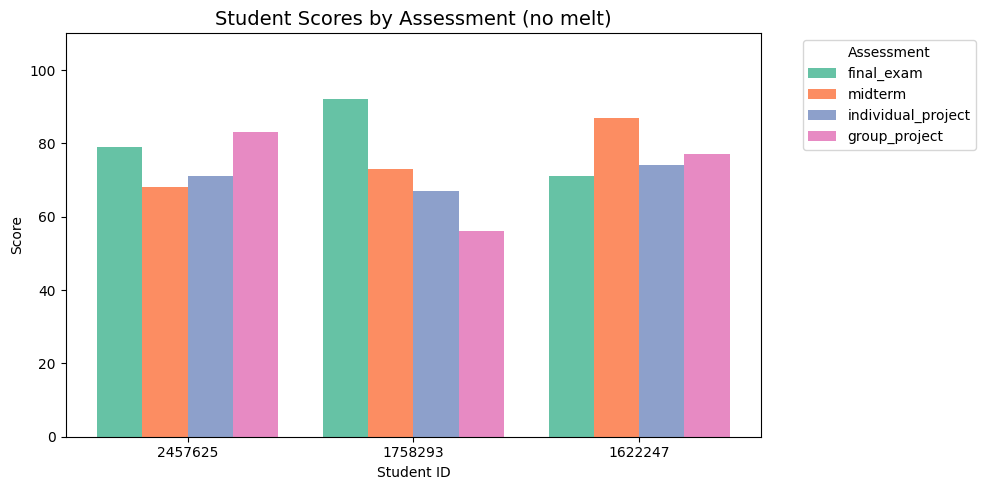

In [4]:
# The four assessment columns we want to plot
assessments = ['final_exam', 'midterm', 'individual_project', 'group_project']

# x = [0, 1, 2] — one integer position per student, used as the base for bar placement
x = range(len(grades_df))

# Each group of bars will share a total width of ~0.8; each individual bar gets 0.2
width = 0.2

# One distinct color per assessment
colors = sns.color_palette('Set2', len(assessments))

fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, color) in enumerate(zip(assessments, colors)):
    # Offset shifts each bar left or right so the group is centered on the tick.
    # e.g. with 4 bars: offsets are -0.3, -0.1, +0.1, +0.3
    offset = (i - len(assessments) / 2) * width + width / 2
    
    # Add xi (student position) + offset to place each bar in the right slot
    ax.bar([xi + offset for xi in x], grades_df[col], width=width, label=col, color=color)

# Place x-ticks at the integer student positions (0, 1, 2)
ax.set_xticks(list(x))

# Replace integer tick positions with the actual student IDs as labels
ax.set_xticklabels(grades_df['student_id'].astype(str))

ax.set_ylim(0, 110)
ax.set_title('Student Scores by Assessment (no melt)', fontsize=14)
ax.set_xlabel('Student ID')
ax.set_ylabel('Score')
ax.legend(title='Assessment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Same idea for a line plot — iterate over rows (students) and call `ax.plot()` for each of them


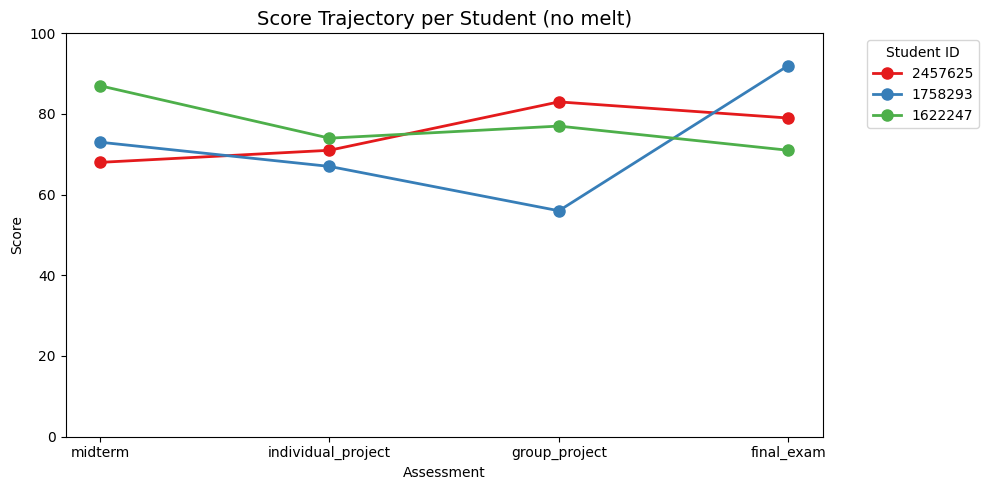

In [5]:
# Assessments in a meaningful chronological order (rather than alphabetical)
assessment_order = ['midterm', 'individual_project', 'group_project', 'final_exam']

# One distinct color per student
colors = sns.color_palette('Set1', len(grades_df))
fig, ax = plt.subplots(figsize=(10, 5))

# df.iterrows() loops over a dataframe one row at a time, yielding two things on each iteration:
# i — the row index (in our case 0, 1, 2)
# row — the entire row as a pandas Series, so you can access individual values by column name with row['student_id'], row['midterm'] etc.

# So for our dataframe, the loop runs 3 times — once per student. On the first iteration i=0 and row contains all the scores for student 2457625, and so on.
# The reason we iterate over rows here is that a line plot needs one line per student, and each student is a row. 
# Each call to ax.plot() inside the loop draws one complete line spanning all assessments for that student.

for i, row in grades_df.iterrows():
    # Extract scores in the order defined above — this is what melt would otherwise handle
    scores = [row[a] for a in assessment_order]
    
    # Plot one line per student, using their ID as the legend label
    ax.plot(
        assessment_order,        # x-axis: the category labels ['midterm', 'individual_project', 'group_project', 'final_exam']
        scores,                  # y-axis: the student's scores in the same order, e.g. [68, 71, 83, 79]
        marker='o',              # shape of the dot drawn at each data point
        linewidth=2,             # thickness of the line connecting the dots
        markersize=8,            # size of each dot
        label=str(row['student_id']),  # text that appears in the legend for this line, e.g. "2457625"
        color=colors[i]          # color of this line, distinct per student
    )

ax.set_ylim(0, 100)
ax.set_title('Score Trajectory per Student (no melt)', fontsize=14)
ax.set_xlabel('Assessment')
ax.set_ylabel('Score')
ax.legend(title='Student ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## With Melting: Cleaner Seaborn Approach
Now the same plots using `melt` — notice how much less code is needed.

## 1. Grouped Bar Plot
Best for **comparing scores across assessments per student**. Easy to read absolute values.

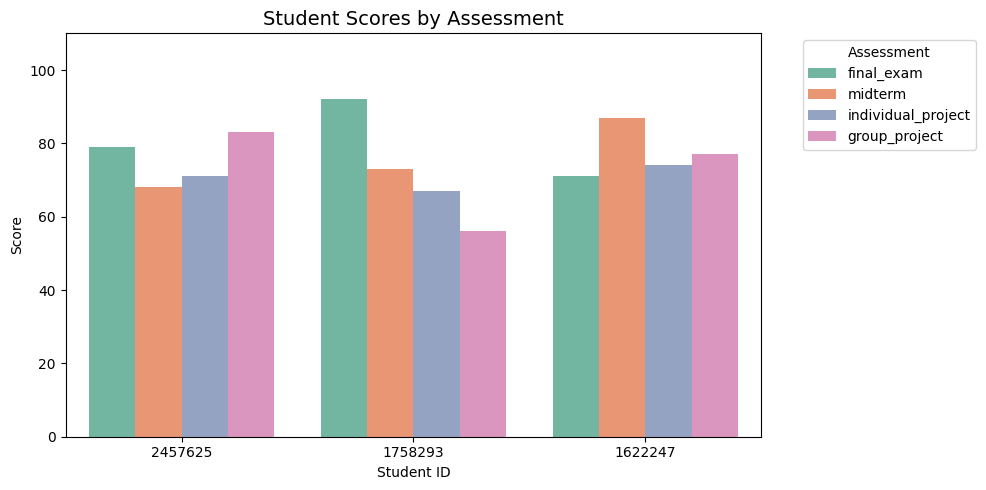

In [9]:
# df_melted is the long-format dataframe: one row per (student, assessment) pair
# hue='assessment' is what tells seaborn to create a separate bar per assessment,
# grouped under each student on the x-axis — this is the dodged layout
plt.figure(figsize=(10, 5))
sns.barplot(data=long_grades_df, 
    x='student_id', 
    hue='assignment_type', 
    y='score', 
    palette='Set2')

plt.ylim(0, 110)
plt.title('Student Scores by Assessment', fontsize=14)
plt.xlabel('Student ID')
plt.ylabel('Score')
plt.legend(title='Assessment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Heatmap
Best for **spotting patterns at a glance** — which students struggled and on which assessments.

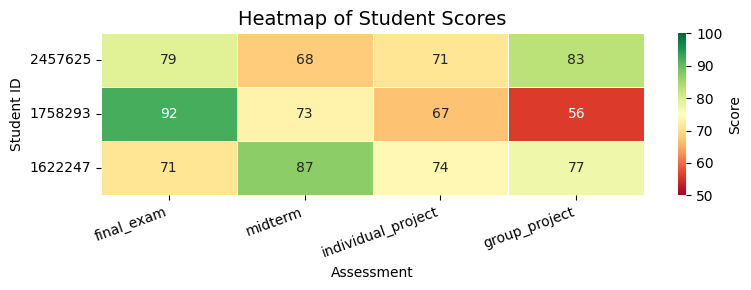

In [10]:
# df_heat is the wide-format dataframe with student_id as the index,
# so rows = students, columns = assessments — exactly what heatmap expects
plt.figure(figsize=(8, 3))
ax = sns.heatmap(
    df_heat,
    annot=True,          # print the actual score value inside each cell
    fmt='d',             # format annotations as integers (no decimal places)
    cmap='RdYlGn',       # red = low, yellow = mid, green = high
    vmin=50,             # anchor the color scale at 50 — scores below this get max red
    vmax=100,            # anchor the top of the color scale at 100
    linewidths=0.5,      # thin lines between cells to visually separate them
    cbar_kws={'label': 'Score'}  # label the colorbar on the right
)
plt.title('Heatmap of Student Scores', fontsize=14)
plt.xlabel('Assessment')
plt.ylabel('Student ID')
plt.xticks(rotation=20, ha='right')  # angle x labels slightly so they don't overlap

# plt.yticks() doesn't work reliably on seaborn heatmaps — need to go via the axes object
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
plt.tight_layout()
plt.show()

## 3. Line Plot
Best for showing **each student's score trajectory** across assessments — highlights rises and dips.

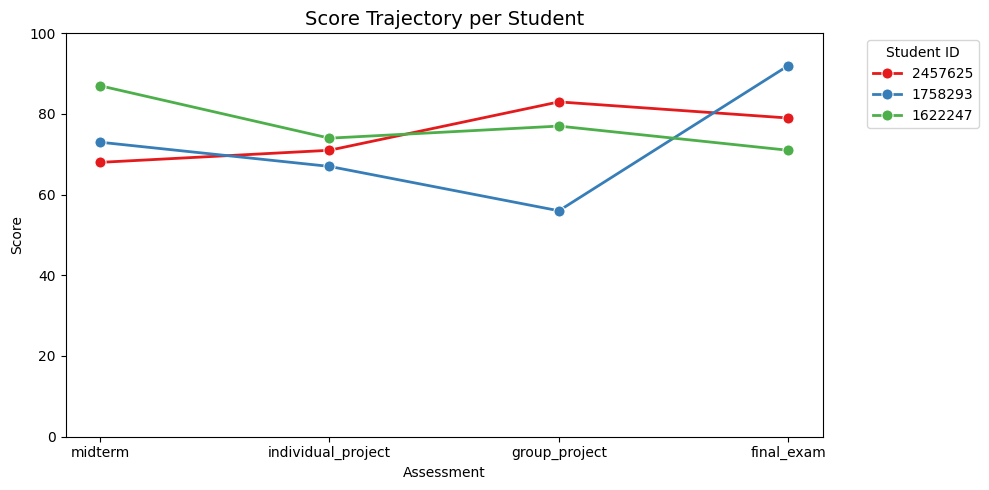

In [ ]:
# Define a logical ordering for the assessments — chronological makes more sense
# than alphabetical so the line shows a meaningful left-to-right progression
assessment_order = ['midterm', 'individual_project', 'group_project', 'final_exam']

# Convert the assessment column to an ordered categorical type — without this,
# seaborn would sort the x-axis alphabetically and ignore our custom order
long_grades_df['assignment_type'] = pd.Categorical(long_grades_df['assignment_type'], 
    categories=assessment_order, 
    ordered=True)

# Sort the dataframe by assessment so the lines are drawn in the correct sequence
df_melted_sorted = long_grades_df.sort_values('assignment_type')

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_melted_sorted,
    x='assignment_type',
    y='score',
    hue='student_id',  # one line per student
    marker='o',        # dot at each data point so individual scores are visible
    linewidth=2,
    markersize=8,
    palette='Set1'
)
plt.ylim(0, 100)   
plt.title('Score Trajectory per Student', fontsize=14)
plt.xlabel('Assessment')
plt.ylabel('Score')
plt.legend(title='Student ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()